## 13.3 적대적 생성 신경망(GAN)이란

처음 적대적 생성 신경망을 제안한 이안 굿펠로우는 GAN을 경찰과 위조지폐범 사이의 게임에 비유했습니다. 위조지폐범은 진짜와 같은 위조 화폐를 만들어 경찰을 속이고, 경찰은 진짜 화폐와 위조 화폐를 판별하여 위조지폐범을 검거합니다. 위조지폐범과 경찰의 경쟁이 지속되면 어느 순간 위조지폐범은 진짜와 같은 위조지폐를 만들 수 있게 되고, 결국 경찰은 위조지폐와 실제 화폐를 구분할 수 없는 상태에 이르게 됩니다.

딥러닝 용어로 설명하자면, 경찰은 진짜 지폐와 위조지폐를 구분하는 판별자가 되며 위조지폐범은 위조지폐를 생성하는 생성자가 됩니다. 생성 모델은 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가짜를 구별하는 판별자가 각각 존재하여 서로 적대적으로 학습합니다.

적대적 학습에서는 판별자를 먼저 학습시킨 후 생성자를 학습시키는 과정을 반복합니다. 판별자 학습은 크게 두 단계로 진행됩니다. 먼저 실제 이미지를 입력해서 네트워크(신경망)가 해당 이미지를 진짜로 분류하도록 학습시킵니다. 그런 다음 생성자가 생성한 모조 이미지를 입력해서 해당 이미지를 가짜로 분류하도록 학습시킵니다. 이 과정을 거쳐 판별자는 실제 이미지를 진짜로 분류하고, 모조 이미지를 가짜로 분류합니다.

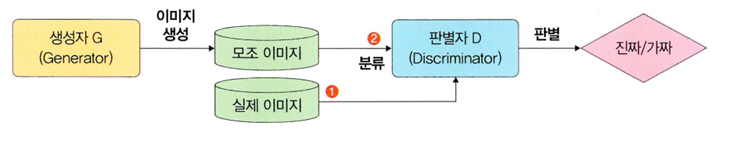

이와 같은 학습 과정을 반복하면 판별자와 생성자가 서로를 적대적인 경쟁자로 인식하여 모두 발전하게 됩니다. 결과적으로 생성자는 진짜 이미지에 완벽히 가까울 정도의 유사한 모조 이미지를 만들고, 이에 따라 판별자는 실제 이미지와 모조 이미지를 구분할 수 없게 됩니다. 즉, 생성자는 분류에 성공할 확률을 낮추고 판별자는 분류에 성공할 확률을 높이면서 서로 경쟁적으로 발전시키는 구조입니다.

### 13.3.1 GAN 동작 원리
적대적 생성 신경망(GAN)은 생성자(Gcnerator)와 판별자(Discrirninator) 네트워크 두 개로 구성되어 있습니다. 이름에서 알 수 있듯이 두 네트워크는 서로 적대적으로 경쟁하여 학습을 진행합니다. 생성자 G는 판별자 D를 속이려고 원래 이미지와 최대한 비슷한 이미지를 만들도록 학습합니다. 반대로 판별자D는 원래 이미지와 생성자 G가 만든 이미지를 잘 구분하도록 학습을 진행합니다.

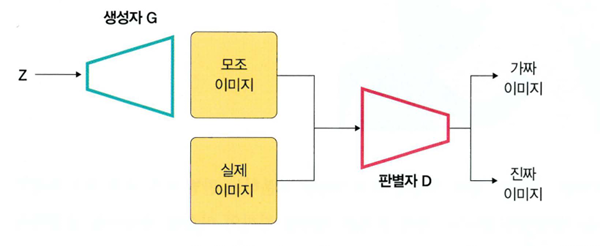

먼저 판별자D부터 살펴보겠습니다. 판별자D의 역할은 주어진 입력 이미지가 진짜 이미지인지 가짜 이미지인지 구별하는 것입니다. 즉 이미지 x가 입력으로 주어졌을 때 판별자D의 출력에 해당하는 D(x)가 진짜 이미지일 획률을 반환합니다.

반면 생성자 G의 역할은 판별자 D가 진짜인지 가짜인지 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용하여 만들어 내는 것입니다. 예를 들어 실제 이미지인 알파뱃 z가 입력으로 주어졌을 때 판별지는 Z를 학습합니다. 또한 생성자는 임의의 노이즈 데이터를 시용하여 모조 이미지 Z'(G(z))를 생성합니다. 이러한 G(z)를 다시 판별자 D의 입력으로 주변 판별자는 G(z)가 실제 이미지일 획률을 반환합니다.

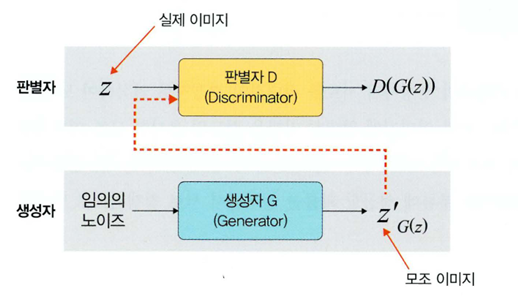

실제 데이터를 판단하려고 판별자 D를 학습시킬 때는 생성자 G를 고정시컨 채 실제 이미지는 높은 확률을 반환하는 방향으로 모조 이미지는 낮은 확률을 반환하는 방향으로 가중치를 업데이트합니다.

GAN 구조를 살펴보았으니, 이제 GAN의 손실 함수를 살펴보겠습니다. 먼저 GAN의 손실 함수는 다음과 같습니다.
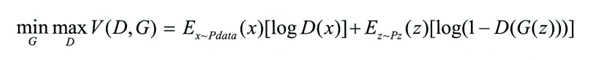

수식에서 판별자 D는 실제 이미지 x를 입력받을 경우 D(x)를 1로 예측하고, 생성자가 잠재 벡터에서 생성한모조 이미지 G(z)를 입력받을 경우D(G(z))를 0으로 예측합니다. 따라서 판별자가 모조 이미지 G(z)를 입력받을 경우 1로 예측하도록 하는 것이 목표입니다.

다시 앞의 손실 함수 전체로 돌아오면 눈으로 보는 것처럼 상당히 복잡해 보입니다. 따라서 판별자D와 생성자 G부분으로 나누어서 살펴보겠습니다. 판별자D는 다음 식의 최댓값으로 파라미터를 업데이트하는 것을 목표로 합니다. 참고로 판별자는 앞의 수식에서 좌항과 우항을 모두 사용합니다.

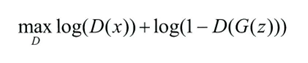

이때 판별자 입장에서는 D(x)=l, D(G(z))=O이 최상의 결과(진짜 이미지는 1, 가짜 이미지는 0을 출력할 경우)가 될 것이기 때문에 이 식의 최멋값으로 업데이트해야 합니다.

또한, 판별자 입장에서는 log(D(x))와 log(l-D(G(z))) 모두 최대가 되어야 합니다. 즉, D(x)는 1이 되어야 실제 이미지를 진짜라고 분류하며, 1-D(G(z))는 1이 되어야 생성자가 만든 모조 이미지를 가짜라고 분류합니다.

반면에 생성자 G는 다음 식의 최솟값으로 파라미터를 업데이트하는 것을 목표로 합니다.

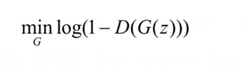

이때 생성자 입장에서는 D(G(z))=l이 최상의 결과(판별자가 가짜 이미지를 1로 출력한 경우)가 될 것이기 때문에 이 식의 최솟값으로 업데이트해야 합니다.

참고로 GAN을 학습시키려면 판별자와 생성자의 파라미터를 번갈아 가며 업데이트해야 합니다. 또한, 판별자의 파라미터를 업데이트할 때는 생성자의 파라미터를 고정시키고, 생성자의 파라미터를 업데이트할 때는 판별자의 파라미터를 고정해야 합니다.

그럼 이제 예제로 GAN의 구현 방법을 알아보겠습니다.

### 13.3.2 GAN 구현
GAN 예제 역시 MNIST 데이터셋을 사용하여 파이토치로 구현하는 방법을 알아보겠습니다.

먼저 필요한 라이브러리를 호출합니다.

In [1]:
import imageio # 이미지 데이터를 읽고 쓸 수 있는 쉬운 인터페이스를 제공하는 라이브러리
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot') # 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1. 맷플롯립 라이브러리는 시각화에 사용합니다. 맷플롯립은 폰트, 색상 등을 변경하여 사용할 수 있는데 에제에서는 스타일시트를 바꾸어서 사용했습니다.

'ggplot' 스타일 시트는 격자무늬의 백그라운드를 삽입하고자 할 때 사용합니다.

필요한 변수에 대한 값을 지정합니다.

In [2]:
batch_size = 512
epochs = 200
sample_size = 64 # 1
nz = 128 # 2
k = 1 # 3

1. 노이즈 벡터를 사용하여 가짜 이미지를 생성합니다. sample_size는 생성자에 제공할 고정 크기의 노이즈 벡터에 대한 크기입니다.

2. 잠재 벡터의 크기를 의미합니다. 이때 잠재 벡터의 크기는 생성자의 입력 크기와 동일해야 합니다.

3. 판별자에 적용할 스텝 수를 의미합니다. 스텝 수를 1로 지정한 이유는 훈련 비용을 최소화하기 위함입니다.

예제에서 진행할 MNIST를 내려받아 정규화를 적용합니다. 이후에는 데이터로더에 데이터를 전달하여 모델의 학습에 사용할 수 있도록 합니다.

In [3]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 31.01 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지를 텐서로 변환
    transforms.Normalize((0.5,),(0.5,)), # 이미지를 평균이 0.5, 표준편차가 0.5가 되도록 정규화
])

train_dataset = datasets.MNIST(root = '080289/chap13/data', train = True, transform = transform, download = True)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


데이터셋이 준비되었기 때문에 네트워크를 생성할 텐데 먼저 생성자 네트워크를 만들어 보겠습니다. 간단한 예제를 위해 네 개의 선형 계층과 세 개의 리키렐루(LeakyReLU) 활성화 함수를 사용합니다.

In [5]:
class Generator(nn.Module):
  def __init__(self, nz):
    super(Generator, self).__init__()
    self.nz = nz
    self.main = nn.Sequential(
        nn.Linear(self.nz, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 1024), nn.LeakyReLU(0.2),
        nn.Linear(1024, 784), nn.Tanh(),
    )

  def forward(self, x):
    return self.main(x).view(-1, 1, 28, 28) # 생성자 네트워크의 반환값은 '배치 크기x1x28x28'이 됩니다.

생성자 네트워크가 완료되었고, 이제 판별자 네트워크를 생성해 보겠습니다. 판별자는 이진 분류자라는 것을 고려하여 신경망을 구축해야 합니다.

In [6]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.n_input = 784 # 판별자의 입력 크기
    self.main = nn.Sequential(
        nn.Linear(self.n_input, 1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
        nn.Sigmoid(),
    )
  def forward(self, x):
    x = x.view(-1, 784)
    return self.main(x) # 이미지가 진짜인지 가짜인지를 분류하는 값을 반환

앞에서 생성한 생성자와 판별자 네트워크를 초기화합니다. 이때 생성자는 잠재 벡터 nz라는 변수를 파라미터로 전달해야 합니다.

In [7]:
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


이제 모델의 네트워크에서 사용할 옵티마이저와 손실 함수를 정의합니다. 중요한 것은 생성자와 판별자에서 사용할 옵티마이저를 따로 정의해야 한다는 것입니다.

In [8]:
optim_g = optim.Adam(generator.parameters(), lr = 0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()

losses_g = [] # 매 에포크마다 발생하는 생성자 오차를 저장하기 위한 리스트형 변수
losses_d = [] # 매 에포크마다 발생하는 판별자 오차를 저장하기 위한 리스트형 변수
images = [] # 생성자에 의해 생성되는 이미지를 저장하기 위한 리스트형 변수

생성자에 의해 만들어지는 새로운 이미지(텐서)를 저장하기 위한 함수를 저장합니다. 이 함수는 모델 학습에 반드시 필요한 것은 아니지만 이미지가 생성되는 과정을 이해할 수 있도록 시각화하여 보여줍니다.

In [9]:
def save_generator_image(image, path):
  save_image(image, path)

판별자를 학습시키기 위한 함수를 정의합니다. 판별자의 학습은 진짜 데이터의 레이블과 가짜 데이터의 레이블을 모두 이용하여 학습합니다.

In [10]:
def train_discriminator(optimizer, data_real, data_fake):
  b_size = data_real.size(0) # 배치 크기 정보 얻기
  real_label = torch.ones(b_size, 1).to(device) # 1
  fake_label = torch.zeros(b_size, 1).to(device) # 2
  optimizer.zero_grad()
  output_real = discriminator(data_real)
  loss_real = criterion(output_real, real_label) # 진짜 데이터를 판별자에 제공하여 학습한 결과와 진짜 데이터의 레이블을 이용하여 오차를 계산
  output_fake = discriminator(data_fake)
  loss_fake = criterion(output_fake, fake_label) # 가짜 데이터를 판별자에 제공하여 학습한 결과와 가짜 데이터의 레이블을 이용하여 오차를 계산
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real + loss_fake # 진짜 데이터와 가짜 데이터의 오차가 합쳐진 최종 오차를 반환

1. GAN에서는 모델 훈련을 위해 진짜 이미지와 생성자에서 생성한 가짜 이미지가 필요합니다. 그뿐만 아니라 레이블 정보도 필요한데, 레이블 정보는 텐서 형태를 가져야 하며 배치 크기와도 동일해야 합니다. 먼저 진짜 데이터에 대한 레이블을 생성합니다.

2. 가짜 데이터에 대한 레이블을 생성합니다.

이제 생성자 학습을 위한 함수를 정의할 텐데, 상대적으로 판별자의 네트워크보다는 간단합니다.

In [11]:
def train_generator(optimizer, data_fake):
  b_size = data_fake.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  optimizer.zero_grad()
  output = discriminator(data_fake)
  loss = criterion(output, real_label)
  loss.backward()
  optimizer.step()
  return loss

1. 생성자 네트워크에서는 가짜 데이터만 사용하고 있는데, 생성자 입장에서는 가짜 데이터가 실제로 진짜라는 것에 주의할 필요가 있습니다.

이제 for 구문을 이용하여 200회 에포크만큼 모델을 학습시킵니다.

In [12]:
batch_size = 64
epochs = 20

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
generator.train() # 생성자를 학습 모드로 설정
discriminator.train() # 판별자를 학습 모드로 설정

for epoch in range(epochs):
  loss_g = 0.0 # 생성자 오차를 추적(저장)하기 위한 변수
  loss_d = 0.0 # 판별자 오차를 추적(저장)하기 위한 변수
  for idx, data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):
    image, _ = data # 학습을 위한 이미지 데이터를 가져옵니다.
    image = image.to(device) # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
    b_size = len(image)
    for step in range(k): # k(1) 스텝 수에 따라 판별자를 실행, 이떄 k 수를 증가시킬 수 있지만 학습 시간이 길어질 수 있으므로 주의
      data_fake = generator(torch.randn(b_size, nz).to(device)).detach() # 1
      data_real = image
      loss_d += train_discriminator(optim_d, data_real, data_fake) # 1'
    data_fake = generator(torch.randn(b_size, nz).to(device))
    loss_g += train_generator(optim_g, data_fake) # 생성자 학습
  generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach() # 생성자를 이용하여 새로운 이미지를 생성하고 CPU 장치를 이용하여 디스크에 저장
  generated_img = make_grid(generated_img)
  save_generator_image(generated_img, f"/content/drive/MyDrive/ESAA/gen_img{epoch}.png") # 생성된 이미지(텐서)를 디스크에 저장
  epoch_loss_g = loss_g / idx # 에포크에 대한 총 생성자 오차 계산
  epoch_loss_d = loss_d / len(train_loader) # 에포크에 대한 총 판별자 오차 계
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f"Epoch {epoch} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
118it [00:56,  2.10it/s]                         


Epoch 0 of 20
Generator loss: 1.32076907, Discriminator loss: 0.89105600


118it [00:52,  2.25it/s]


Epoch 1 of 20
Generator loss: 2.86948991, Discriminator loss: 1.08728242


118it [00:56,  2.09it/s]


...

Epoch 17 of 20
Generator loss: 3.07165861, Discriminator loss: 0.38404542


118it [00:54,  2.15it/s]


Epoch 18 of 20
Generator loss: 3.16343260, Discriminator loss: 0.30009666


118it [00:54,  2.16it/s]


Epoch 19 of 20
Generator loss: 3.59124136, Discriminator loss: 0.25291899


1. 생성자에서 새로운 이미지 데이터(텐서)를 생성하기 위해서는 노이즈 데이터가 필요합니다. 노이즈 데이터를 troch.randn()을 이용해서 생성할 수 있습니다.

이번에는 생성자와 판별자의 오차에 대한 변화를 그래프로 살펴보겠습니다.

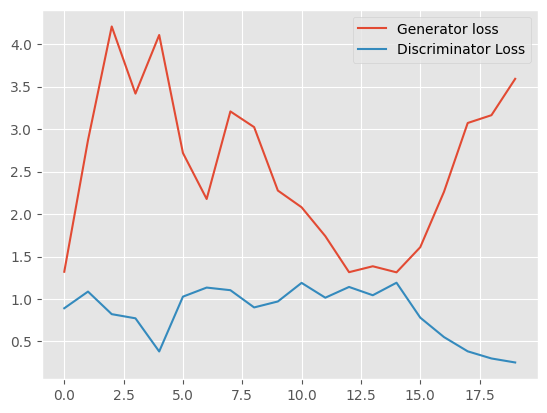

In [15]:
plt.figure()
losses_g = [fl.item() for fl in losses_g]
plt.plot(losses_g, label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d, label='Discriminator Loss')
plt.legend()

처음 몇 에포크 동안 생성자의 오치는 증가하고 판별자의 오차는 감소하는 것을 볼 수 있습니다.

이러한 증상이 나타나는 이유는 학습 초기 단계에 생성자는 좋은 가짜 이미지를 생성하지 못하기에 판별자가 실제 이미지와 가짜 이미지를 쉽게 구분할 수 있기 때문입니다. 하지만 학습이 진행됨에 따라 생성지는 진짜와 같은 가짜 이미지를 만들며 판별자는 가짜 이미지 중 일부를 진짜로 분류합니다. 따라서 그림과 같이 생성자의 오차가 감소하면 판별자의 오차는 증가합니다.

앞의 이미지를 하나씩 쪼개서 확인하고 싶다면 다음 코드와 같이 실행하면 됩니다. 생성된 열 개의 이미지를 보여 줍니다.

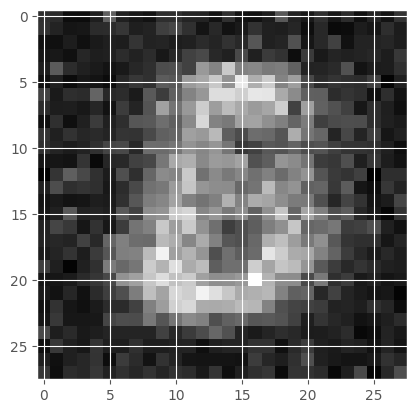

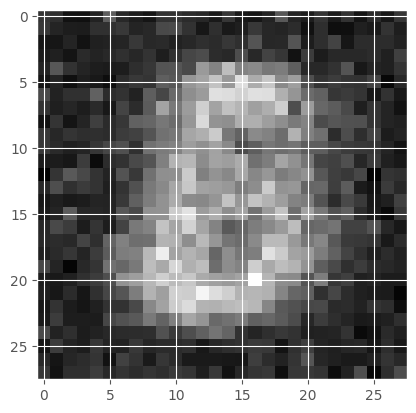

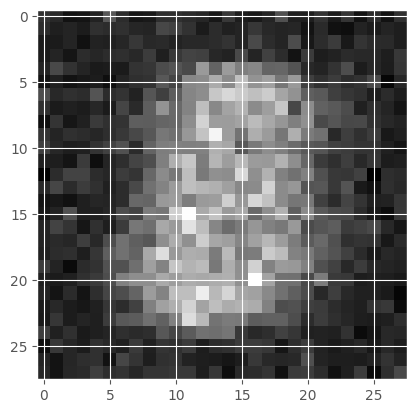

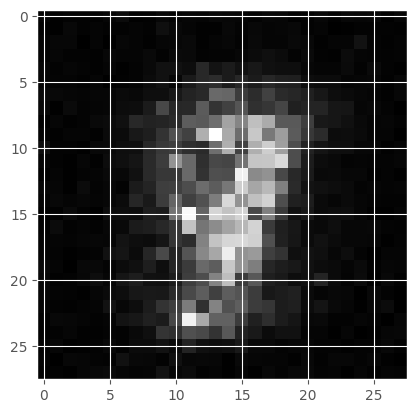

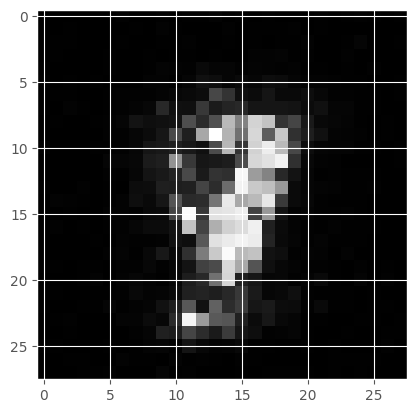

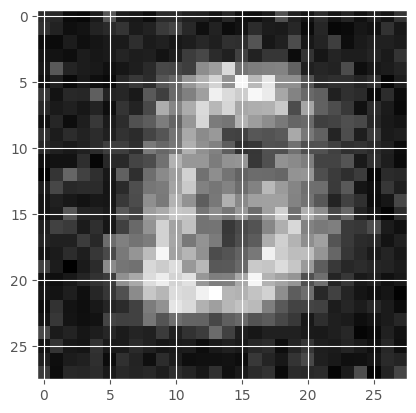

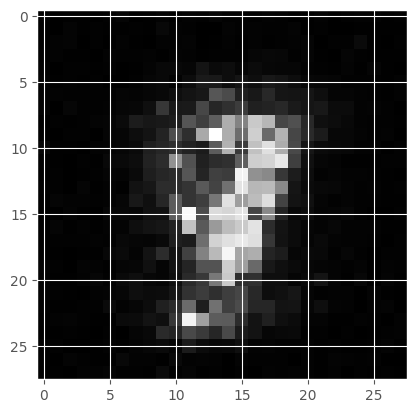

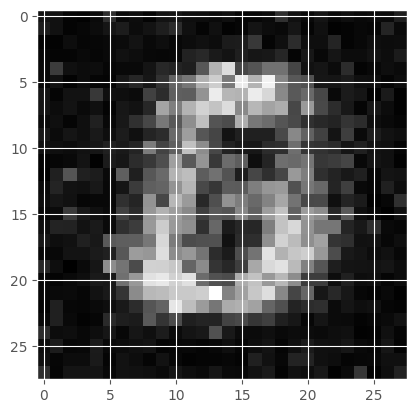

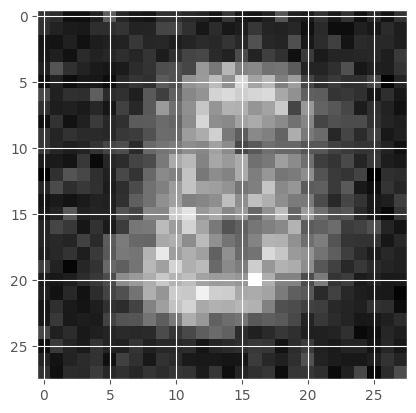

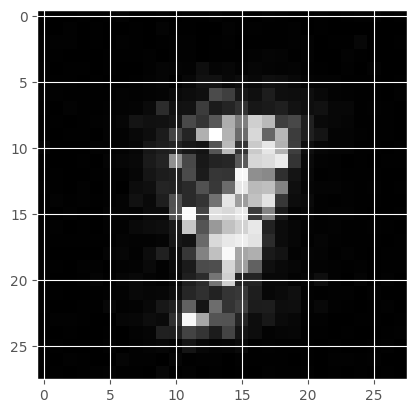

In [16]:
import numpy as np

fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
  fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
  plt.imshow(fake_images_img, cmap='gray')
  plt.savefig('/content/drive/MyDrive/ESAA/fake_images_img' + str(i) + '.png')
  plt.show()

 에포크를 사용하여 학습 횟수를 늘리면 더 선명한 결과를 얻을 수 있습니다.

 ## 13.4 GAN 파생 기술

GAN은 생성자와 판별자가 서로 대결하면서 학습하는 구조이기 때문에 학습이 매우 불안정합니다. 생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류(진짜 혹은 가짜 분류)가 불가능합니다. 이러한 제약을 해결한 모댈이 DCGAN입니다. 이름에서도 알 수 있듯이 DCGAN은 GAN 학습에 CNN을 사용하는 것입니다.

GAN과 DCGAN이 가짜 이미지 생성을 위해 임의의 노이즈 값을 사용했다면 cGAN은 출력에 어떤 조건을 주어 변형하는 모넬입니다. 즉, GAN이 임의의 노이즈로 무작위 이미지를 출력한다면, cGAN은 시드 역할을 하는 임의의 노이즈와 함께 어떤 조건이 추가됩니다. 조건이 추가되고 데이터 훈련 과정에서 인간이 통제할 수 있게 되면서 실제 이미지와 가깝거나 원래 이미지에 없던 문자열 태그 등도 넣는 것이 가능해졌습니다.

또한, CycleGAN이라는 것도 있습니다. CycleGAN은 사진이 주어졌을 때 다른 사진으로 변형시키는 모델입니다.

그럼 DCGAN을 먼저 살펴보겠습니다.

### 13.4.1 DCGAN
DCGAN은 GAN과 동일하게 입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들고, 이를 평가하는 과정을 반복하여 실제와 매우 유사한 이미지를 생산하는 학습법입니다. 따라서 DCGAN 역시 생성자와 판별자 네트워크 두 개가 서로 적대적으로 학습하는 구조입니다.

**생성자 네트워크**
생성자는 임의의 입력을 받아들여 판별자에서 사용할 수 있는 이미지 데이터를 생성하며, 출력은 64x64가됩니다. 임의의 입력으로 주어지는 노이즈 데이터는'가로x세로'형태가 아니기 때문에 입력 형태를 '가로x세로'로 변경해야 합니다. 형태가 변경된 입력은 합성곱층으로 넘겨진 후 이미지 형태의 출력을 위해 분수-스트라이드 합성곱을 사용하
여 출력값을 키웁니다.

생성자 네트워크 특정은 다음과 같습니다.

- 풀링층을 모두 없애고, 분수-스트라이드 합성곱을 사용합니다.
- 배치 정규화를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산할 수 있도록 했습니다. 단 배치 정규회를 모든 계층마다 추가할 경우 안정성이 떨어지는 문제가 있으므로 최종 출력층에서는 사용하지 않았습니다.
- 활성화 함수는 렐루(RcLU)를 사용하며 최종 출력층에서는 하이퍼볼릭 탄젠트(tanh)를 사용합니다.

**판별자 네트워크**
판별자 네트워크는 64x64 크기의 이미지를 입력받아 진짜 혹은 가짜의 1차원 결과를 출력합니다. 활성화 함수로 리거벨루(LeakyHeLU)를 시용하며 최종 출력층에서는 시그모이드 함수를 사용하여 0~1의 값을 출력합니다.

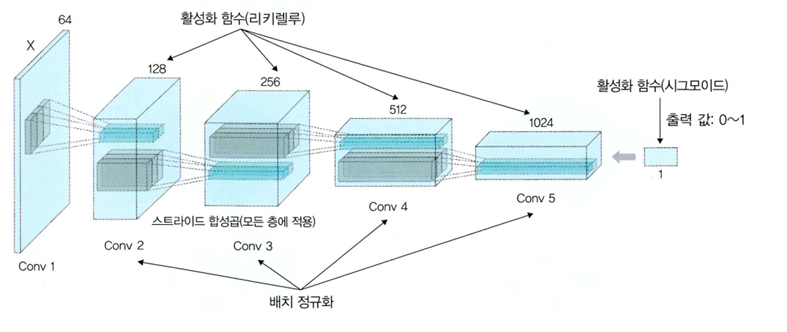

즉, 판별자 네트워크 특징은 다음과 같습니다.

- 풀링층을 모두 없애고， 스트라이드 합성곱을 시용합니다.
- 배치 정규회를 이용하여 네트워크의 층이 많아도 안정적으로 기울기를 계산할 수 있도록 했습니다. 단 생성자 네트워크와 마찬가지로 배치 정규화를 모든 계층마다 추가하면 안정성이 떨어지는 문제가 있으므로 최초 입력층에서는 사용하지 않았습니다.
- 활성화 함수는 리키렐루를 사용하며 최종 출력층에서는 시그모이드를 사용합니다.

### 13.4.2 cGAN
cGAN은 GAN의 출력에 조건을 주어 통제하려는 시도에서 만들어졌습니다. 기존 GAN은 노이즈 벡터를 받아들여서 출력을 만들어 내는데 이때 사람이 통제할 수 있는 부분이 없었습니다. 그렇다면 통제는 왜 필요할까요?

GAN을 이용하면 입력 이미지와 유사한 출력 이미지가 생성되었습니다. 그런데 입력 이미지에 새로운 객제를 추가하거나 이미지에 자동으로 문자열 태그를 붙이고 싶다면 어떻게 해야 할까요? 기존 GAN 기술을 이용할 때는 불기능했습니다. 하지만 cGAN을 이용하여 조건을 변경한다면 이 모든 것이 가능합니다.

cGAN 원리를 좀 더 자세히 살펴보겠습니다.

기본적으로 GAN 원리와 비슷하지만 다음 그림과 같이 생성자와 판별자에 조건을 입력하는 부분에서 차이가 있습니다.

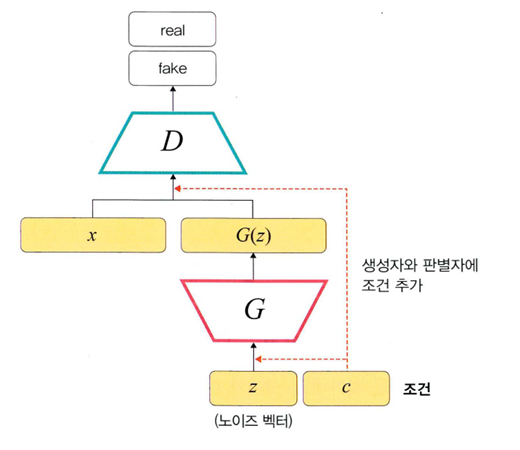

예를 들어 MNIST 데이터셋을 사용하여 데이터를 훈련시킨 후 숫자 1을 출력한다고 합시다. 이때 생성자에 노이즈 벡터와 더불어 그것을 뭇히는 조건 C(Condition C)를 넣어 줍니다. 물론 판별자에도 조건 C([0,0,1)가 추가되어야 합니다.

이러한 방식으로 생성자와 판별자에 조건이 추가되면서 이미지에 대한 변형(기존 이미지에서 변형된 이미지를 생성)이 가능하게 됩니다.

### 13.4.3 CycleGAN
GAN과 DCGAN은 랜덤 노이즈를 입력으로 하므로 무작위 데이터가 생성되기 때문에 원하는 결과를 얻기 어려운 문제가 있습니다. 이러한 문제를 해결하는 방법으로 PIX2PIX가 있습니다.

**PIX2PIX**
PIX2PIX는 임의의 노이즈 벡터가 아닌 이미지를 입력으로 받아 다른 스타일의 이미지를 출력하는 지도 학습 알고리즘입니다. 따라서 PIX2PIX를 학습하려면 입력을 위한 데이터셋과 PIX2PIX를 거쳐서 나올 정답 이미지가 필요합니다.

PIX2PIX의 훈련 역시 생성자와 판별자 네트워크를 이용하는데, 하나씩 살펴보겠습니다.

**생성자 네트워크**
PIX2PIX의 생성자 네트워크는 일반적인 생성자의 구조와 조금 다릅니다. 입력과 출력이 모두 이미지이기 때문에 전체적으로 크기가 줄어들었다가 다시 커지는 인코더 디코더의 구조입니다. 크기가 줄어드는 인코더에서는 입력 데이터의 특정을 찾아내고 크기가 다시 커지는 디코더에서는 이미지를 생성히는 역할을 합니다. 출력층의 활성화 함수는 하이퍼볼릭 탄젠트로 -1~1 사이의 값을 갖습니다. 그렇기 때문에 입력 또한 -1~1 사이의 값으로 변경해서 사용해야 합니다.

**판별자 네트워크**
판별자 네트워크는 DCGAN과 마찬가지로 스트라이드가 2인 합성곱층으로 구성되어 있습니다. 하지만 뒤의 두 계층은 스트라이드가 1인 밸리드 합성곱을 이용하여 최종적으로 30X30 형태의 데이터를출력합니다. 일반적인 GAN 모델의 출력이 0~1 사이의 스칼라인 것과는 차이가 있는데 출력에서 차이가 있는 이유는 판별지를 이미지의 각 부분별로 진행하기 위해서입니다. 즉, 판별자는 이미지를 통째로 진짜인지 아닌지 판별하는 것이 아니라 이미지의 각 부분이 진짜인지 아닌지 판별합니다. 이 과정에 따라 좀 더 디테일한 부분에 집중한 이미지를 판별할 수 있습니다.

또한, PIX2PIX의 훈련을 위한 손실 함수는 다음과 같습니다.

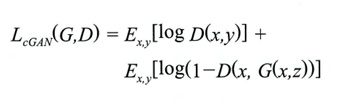

이떄 생성자는 판별자를 속이는 것 말고도 생성한 이미지가 정답(입력 이미지)과 같아야 하는 과제가 있습니다. 이를 위해 PIX2PIX에서는 L1 손실 함수를 사용하며 수식은 다음과 같습니다.

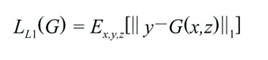

따라서 L1 손실 함수가 추가된 최종 손실 함수는 다음과 같이 수정하여 사용됩니다.

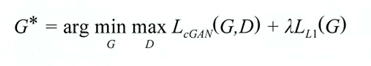

**CycleGAN**
PIX2PIX가 강력한 모델이기는 하지만 데이터 쌍이 필요하다는 단점이 있습니다. 예를 들어 다음 그림의 PIX2PIX 모델처럼 신발의 외곽선(에지)만 표현된 이미지에서 완전한 신발 이미지를 생성하고 싶다면, 선발의 외곽선(에지) 이미지(x)와 신발 이미지(y)에 대한 데이터 쌍이 필요합니다.

그런데 이러한 데이터 쌍의 이미지를 구하는 것이 쉽지 않습니다. 예를 들어 흑백 이미지를 컬러 이미지로 변경하고 싶다면 동일한 그림에서 채색의 유무만 다른 이미지 두 개가 필요한데, 이러한 데이터를 얻기 어렵기 때문에 PIX2PIX 모델을 시용하기가 쉽지 않습니다. 따라서 쌍을 이루지 않는 이미지로 학습할 수 있는 방법이 필요한데 이때 사용하는 것이 CycleGAN입니다.

그럼 이제 CycleGAN을 자세히 살펴보겠습니다.

CycleGAN은 하나가 아닌 두 개(G, F)의 생성자를 갖습니다.

생성자G는 이미지X를 이미지 Y로 변환하며 생성자F는 이미지 Y를 다시 이미지X로 변환합니다. 이때 Dx와 Dy는 각각 이미지 X와 Y를 위한 판별자입니다. 따라서 생성자 G는 Dy에 대한 적대적 학습을 하며, 생성자F는 Dx에 대한 적대적 학습을 합니다.

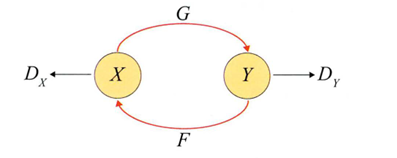

생성자 G는 조랑말 이미지 X를 얼룩말 이미지 Y'로 바꾸어 주며, 생성자 F는 얼룩말 이미지 Y'를 조랑말 이미지 X'로 바꾸어 줍니다. 이때 G(X)는 조랑말 이미지 X가 생성자 G를 통해 변환된 이미지가 되며 함수 적용 결과는 얼룩말 Y'가 됩니다.x가 얼마나X'와 가까운지는 L1 손실 함수를 시용해서 계산합니다. 또한 F(Y')는 얼룩말 이미지 Y'를 생성자 F를 통해 조랑말 X'로 변환합니다. 즉, CycleGAN에서는 G(X)=Y'에 대한 생성자, Y' 값을 다시 X'로 복원하는 F(Y')=x'에 대한 생성자와 이 값을 판별하는 판별자(Dy, Dx)가 추가되어 총 네 개의 네트워크를 사용합니다. 이때 X->Y', Y'->X'로 연결되는 것을 순환 일관성이라고 합니다. 다음 그림은 X->Y', Y'->X'로 연결되는 동작 과정을 보여 줍니다.X->Y'를 정방향 일관성 이라고 하며, Y'->X'를 역방향 일관성이라고 합니다.

또한， 이때 사용되는 순환 일관성 손실 함수(Lcyc(G, F))의 수학적 정의는 다음과 같습니다.

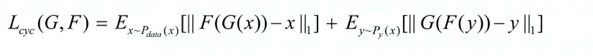

G(x)로 나온y 값을 다시 F(y)를통해 원본 이미지로 복원하고, 마찬가지로 F(y)로 나온x 값을 다시 G(x)를 통해 y로 복원하는 원리를 이용해서 전체 손실에 대한 함수를 정의하면 다음과 같습니다.

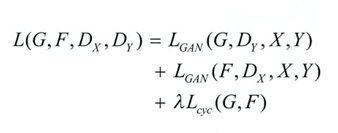

따라서 CycleGAN의 최종 목표는 다음 수식을 푸는 것이라고 할 수 있습니다.

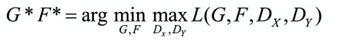

지금까지 학습한 CycleGAN을 정 리하면 다음과 같습니다.

CycleGAN은 PIX2PIX처럼 생성자 하나, 판별자 하나를 시용하는 대신 생성자 둘, 판별자 둘을 사용합니다. 따라서 CycleGAN은 이미지 X에서 이미지 Y로 변환하는 것뿐만 아니라 역방향으로도 변환이 진행됩니다. 그리고 생성자를 학습할 때는 손실 함수 Lcyc를 사용합니다. 즉, CycleGAN은 PIX2PIX와 다르게(PIX2PIX 모델 학습은 L1 손실 함수에 의존적이므로 상대적으로 GAN 손실 함수의 역할이 작음) GAN 손실 함수가 핵심적인 역할을 하기 때문에 더 유연하게 이미지를 변환할 수 있습니다.